In [1]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt

# define and load file
infile = 'data/m50n512_151.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2023-11-01 21:15:29,578 Opening data/m50n512_151.hdf5
yt : [INFO     ] 2023-11-01 21:15:29,652 Found 58101 halos
yt : [INFO     ] 2023-11-01 21:15:29,665 Found 6922 galaxies


In [2]:
from functions import *
unit = 'Mpc/h'

#### Comparison between real distance and different projections

In [15]:
# get the galaxies ordered by age
gal = {i: i.ages["mass_weighted"] for i in obj.galaxies}
sorted(gal.values())
gal_sorted = sorted(gal, key=gal.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit = len(gal_sorted)//4
less = gal_sorted[:limit] #young
more = gal_sorted[-limit:] #old
print(len(gal_sorted))
print(len(more))
print(len(less))

6922
1730
1730


In [16]:
# generate random points 4 four times the number of the selected galaxies
ngal = len(more)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj.simulation.boxsize.to(unit), (ngal*4,3))

In [17]:
# calculate the 2pcf old galaxies
old1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
old2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojection_axis=0,
    binnumber= 10
)
old3 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojection_axis=1,
    binnumber= 10
)
old4 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojection_axis=2,
    binnumber= 10
)

In [18]:
# calculate 2pcf young galaxies
young1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
young2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojection_axis=0,
    binnumber= 10
)
young3 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojection_axis=1,
    binnumber= 10
)
young4 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less]),
    positions2= ran_ngal_x4,
    boxsize= obj.simulation.boxsize,
    isprojection_axis=2,
    binnumber= 10
)

In [19]:
# estimate the uncertainty using k-fold
uncertain1_old1 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain1_young1 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj= False,
    number_bin= 10
)

uncertain1_old2 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj_ax= 0,
    number_bin= 10
)
uncertain1_young2 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj_ax= 0,
    number_bin= 10
)

uncertain1_old3 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj_ax= 1,
    number_bin= 10
)
uncertain1_young3 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj_ax= 1,
    number_bin= 10
)

uncertain1_old4 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain1_young4 = find_uncertainty_kfold(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)

In [20]:
# estimate the uncertainty using bootstrap
uncertain2_old1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain2_young1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj= False,
    number_bin= 10
)

uncertain2_old2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj_ax= 0,
    number_bin= 10
)
uncertain2_young2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj_ax= 0,
    number_bin= 10
)

uncertain2_old3 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj_ax= 1,
    number_bin= 10
)
uncertain2_young3 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj_ax= 1,
    number_bin= 10
)

uncertain2_old4 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain2_young4 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less]),
    pos_random= ran_ngal_x4,
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)

In [21]:
# estimate the uncertainty using cosmic variance
uncertain3_old1 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain3_young1 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj= False,
    number_bin= 10
)

uncertain3_old2 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj_ax= 0,
    number_bin= 10
)
uncertain3_young2 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj_ax= 0,
    number_bin= 10
)

uncertain3_old3 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj_ax= 1,
    number_bin= 10
)
uncertain3_young3 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj_ax= 1,
    number_bin= 10
)

uncertain3_old4 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain3_young4 = find_uncertainty_cosmic_var(
    data= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)

In [22]:
# checking the x values
print('young:')
print(young1[0])
print('k-fold:')
print(uncertain1_young1[0])
print('bootstrap:')
print(uncertain2_young1[0])
print('cosmic variance:')
print(uncertain3_young1[0])

young:
[ 1.23937882  1.71813645  2.42610297  3.47301385  5.02114132  7.31044663
 10.69577434 15.70185355 23.10463141 34.05154571]
k-fold:
[ 1.23937882  1.71813645  2.42610297  3.47301385  5.02114132  7.31044663
 10.69577434 15.70185355 23.10463141 34.05154571]
bootstrap:
[ 1.23937882  1.71813645  2.42610297  3.47301385  5.02114132  7.31044663
 10.69577434 15.70185355 23.10463141 34.05154571]
cosmic variance:
[ 1.45182697  2.35548091  4.07572529  7.35047528 13.58446599]


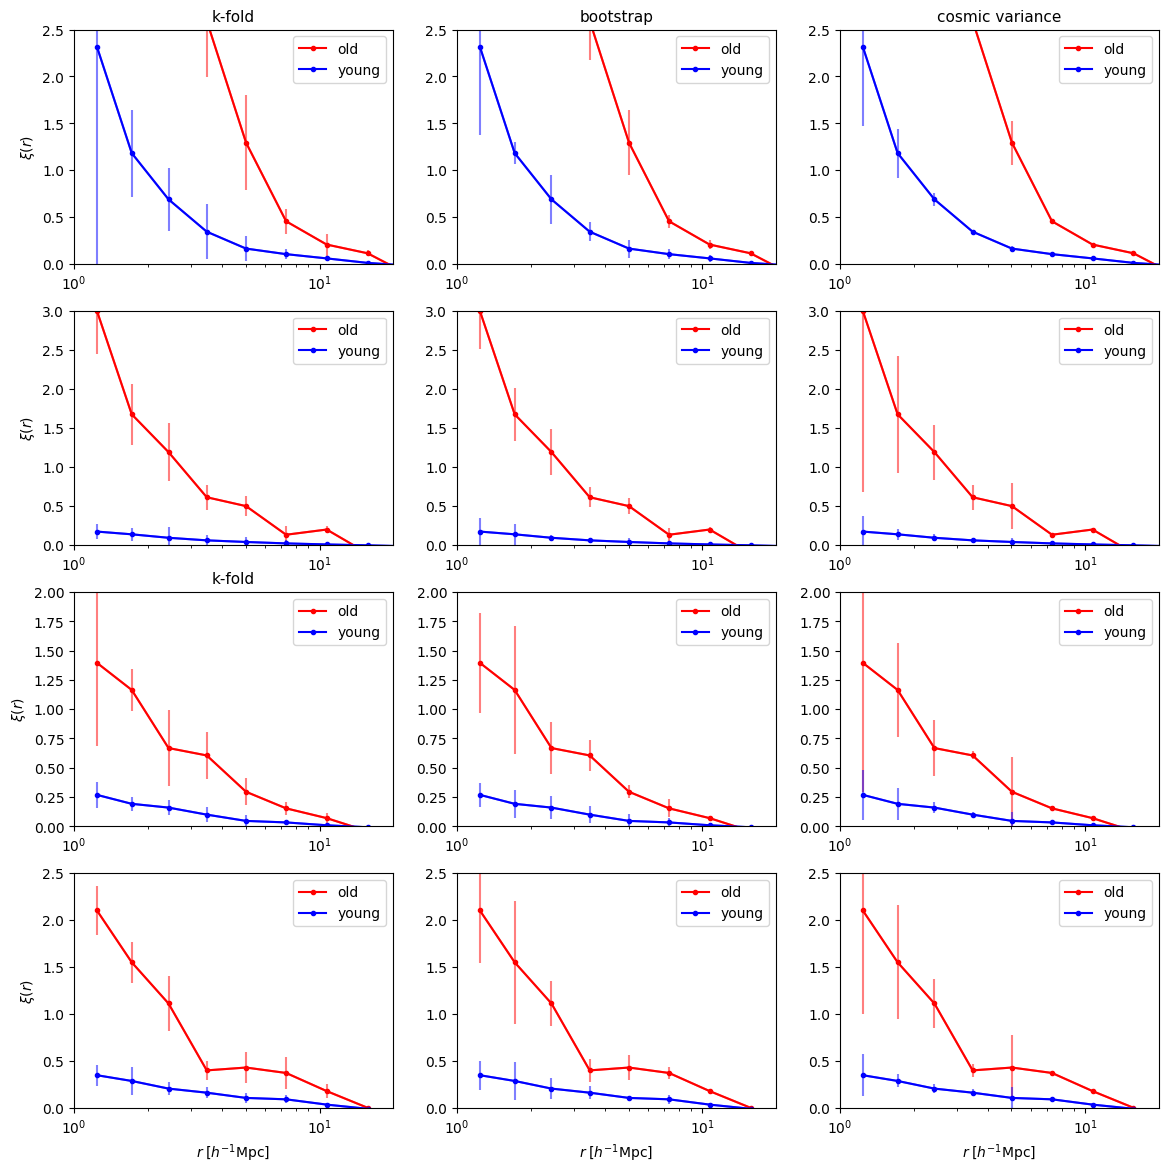

In [23]:
# plot
fig,ax = plt.subplots(4,3, figsize=(14, 14))

# with uncertainty using k-fold
ax[0][0].plot(old1[0],old1[1], marker = '.',
        color= 'Red', label = 'old')
ax[0][0].errorbar(old1[0], old1[1],
        yerr=uncertain1_old1[1], color= 'Red', alpha = .5)
ax[0][0].plot(young1[0],young1[1], marker = '.',
        color= 'Blue', label = 'young')
ax[0][0].errorbar(young1[0], young1[1],
        yerr=uncertain1_young1[1], color= 'Blue', alpha = .5)
#ax[0][0].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
ax[0][0].set_ylabel(r"$\xi (r)$")
ax[0][0].set_title('k-fold', fontsize=11)
ax[0][0].set_ylim(0,2.5)
ax[0][0].set_xlim(10e-1,10**(1.3))
ax[0][0].set_xscale('log')
ax[0][0].legend()

# with uncertainty using bootstrap
ax[0][1].plot(old1[0],old1[1], marker = '.',
        color= 'Red', label = 'old')
ax[0][1].errorbar(old1[0], old1[1],
        yerr=uncertain2_old1[1], color= 'Red', alpha = .5)
ax[0][1].plot(young1[0],young1[1], marker = '.',
        color= 'Blue', label = 'young')
ax[0][1].errorbar(young1[0], young1[1],
        yerr=uncertain2_young1[1], color= 'Blue', alpha = .5)
#ax[0][1].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[0][1].set_ylabel(r"$\xi (r)$")
ax[0][1].set_title('bootstrap', fontsize=11)
ax[0][1].set_ylim(0,2.5)
ax[0][1].set_xlim(10e-1,10**(1.3))
ax[0][1].set_xscale('log')
ax[0][1].legend()

# with uncertainty using cosmic variance
ax[0][2].plot(old1[0],old1[1], marker = '.',
        color= 'Red', label = 'old')
ax[0][2].errorbar(old1[0], old1[1],
        yerr=uncertain3_old1[1], color= 'Red', alpha = .5)
ax[0][2].plot(young1[0],young1[1], marker = '.',
        color= 'Blue', label = 'young')
ax[0][2].errorbar(young1[0], young1[1],
        yerr=uncertain3_young1[1], color= 'Blue', alpha = .5)
#ax[0][2].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[0][2].set_ylabel(r"$\xi (r)$")
ax[0][2].set_title('cosmic variance', fontsize=11)
ax[0][2].set_ylim(0,2.5)
ax[0][2].set_xlim(10e-1,10**(1.3))
ax[0][2].set_xscale('log')
ax[0][2].legend()


ax[1][0].plot(old2[0],old2[1], marker = '.',
        color= 'Red', label = 'old')
ax[1][0].errorbar(old2[0], old2[1],
        yerr=uncertain1_old2[1], color= 'Red', alpha = .5)
ax[1][0].plot(young2[0],young2[1], marker = '.',
        color= 'Blue', label = 'young')
ax[1][0].errorbar(young2[0], young2[1],
        yerr=uncertain1_young2[1], color= 'Blue', alpha = .5)
#ax[1][0].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
ax[1][0].set_ylabel(r"$\xi (r)$")
#ax[1][0].set_title('k-fold', fontsize=11)
ax[1][0].set_ylim(0,3)
ax[1][0].set_xlim(10e-1,10**(1.3))
ax[1][0].set_xscale('log')
ax[1][0].legend()

# with uncertainty using bootstrap
ax[1][1].plot(old2[0],old2[1], marker = '.',
        color= 'Red', label = 'old')
ax[1][1].errorbar(old2[0], old2[1],
        yerr=uncertain2_old2[1], color= 'Red', alpha = .5)
ax[1][1].plot(young2[0],young2[1], marker = '.',
        color= 'Blue', label = 'young')
ax[1][1].errorbar(young2[0], young2[1],
        yerr=uncertain2_young2[1], color= 'Blue', alpha = .5)
#ax[1][1].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[1][1].set_ylabel(r"$\xi (r)$")
#ax[1][1].set_title('bootstrap', fontsize=11)
ax[1][1].set_ylim(0,3)
ax[1][1].set_xlim(10e-1,10**(1.3))
ax[1][1].set_xscale('log')
ax[1][1].legend()

# with uncertainty using cosmic variance
ax[1][2].plot(old2[0],old2[1], marker = '.',
        color= 'Red', label = 'old')
ax[1][2].errorbar(old2[0], old2[1],
        yerr=uncertain3_old2[1], color= 'Red', alpha = .5)
ax[1][2].plot(young2[0],young2[1], marker = '.',
        color= 'Blue', label = 'young')
ax[1][2].errorbar(young2[0], young2[1],
        yerr=uncertain3_young2[1], color= 'Blue', alpha = .5)
#ax[1][2].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[1][2].set_ylabel(r"$\xi (r)$")
#ax[1][2].set_title('cosmic variance', fontsize=11)
ax[1][2].set_ylim(0,3)
ax[1][2].set_xlim(10e-1,10**(1.3))
ax[1][2].set_xscale('log')
ax[1][2].legend()


ax[2][0].plot(old3[0],old3[1], marker = '.',
        color= 'Red', label = 'old')
ax[2][0].errorbar(old3[0], old3[1],
        yerr=uncertain1_old3[1], color= 'Red', alpha = .5)
ax[2][0].plot(young3[0],young3[1], marker = '.',
        color= 'Blue', label = 'young')
ax[2][0].errorbar(young3[0], young3[1],
        yerr=uncertain1_young3[1], color= 'Blue', alpha = .5)
#ax[2][0].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
ax[2][0].set_ylabel(r"$\xi (r)$")
ax[2][0].set_title('k-fold', fontsize=11)
ax[2][0].set_ylim(0,2)
ax[2][0].set_xlim(10e-1,10**(1.3))
ax[2][0].set_xscale('log')
ax[2][0].legend()

# with uncertainty using bootstrap
ax[2][1].plot(old3[0],old3[1], marker = '.',
        color= 'Red', label = 'old')
ax[2][1].errorbar(old3[0], old3[1],
        yerr=uncertain2_old3[1], color= 'Red', alpha = .5)
ax[2][1].plot(young3[0],young3[1], marker = '.',
        color= 'Blue', label = 'young')
ax[2][1].errorbar(young3[0], young3[1],
        yerr=uncertain2_young3[1], color= 'Blue', alpha = .5)
#ax[2][1].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[2][1].set_ylabel(r"$\xi (r)$")
#ax[2][1].set_title('bootstrap', fontsize=11)
ax[2][1].set_ylim(0,2)
ax[2][1].set_xlim(10e-1,10**(1.3))
ax[2][1].set_xscale('log')
ax[2][1].legend()

# with uncertainty using cosmic variance
ax[2][2].plot(old3[0],old3[1], marker = '.',
        color= 'Red', label = 'old')
ax[2][2].errorbar(old3[0], old3[1],
        yerr=uncertain3_old3[1], color= 'Red', alpha = .5)
ax[2][2].plot(young3[0],young3[1], marker = '.',
        color= 'Blue', label = 'young')
ax[2][2].errorbar(young3[0], young3[1],
        yerr=uncertain3_young3[1], color= 'Blue', alpha = .5)
#ax[2][2].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[2][2].set_ylabel(r"$\xi (r)$")
#ax[2][2].set_title('cosmic variance', fontsize=11)
ax[2][2].set_ylim(0,2)
ax[2][2].set_xlim(10e-1,10**(1.3))
ax[2][2].set_xscale('log')
ax[2][2].legend()


ax[3][0].plot(old4[0],old4[1], marker = '.',
        color= 'Red', label = 'old')
ax[3][0].errorbar(old4[0], old4[1],
        yerr=uncertain1_old4[1], color= 'Red', alpha = .5)
ax[3][0].plot(young4[0],young4[1], marker = '.',
        color= 'Blue', label = 'young')
ax[3][0].errorbar(young4[0], young4[1],
        yerr=uncertain1_young4[1], color= 'Blue', alpha = .5)
ax[3][0].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
ax[3][0].set_ylabel(r"$\xi (r)$")
#ax[3][0].set_title('k-fold', fontsize=11)
ax[3][0].set_ylim(0,2.5)
ax[3][0].set_xlim(10e-1,10**(1.3))
ax[3][0].set_xscale('log')
ax[3][0].legend()

# with uncertainty using bootstrap
ax[3][1].plot(old4[0],old4[1], marker = '.',
        color= 'Red', label = 'old')
ax[3][1].errorbar(old4[0], old4[1],
        yerr=uncertain2_old4[1], color= 'Red', alpha = .5)
ax[3][1].plot(young4[0],young4[1], marker = '.',
        color= 'Blue', label = 'young')
ax[3][1].errorbar(young4[0], young4[1],
        yerr=uncertain2_young4[1], color= 'Blue', alpha = .5)
ax[3][1].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[3][1].set_ylabel(r"$\xi (r)$")
#ax[3][1].set_title('bootstrap', fontsize=11)
ax[3][1].set_ylim(0,2.5)
ax[3][1].set_xlim(10e-1,10**(1.3))
ax[3][1].set_xscale('log')
ax[3][1].legend()

# with uncertainty using cosmic variance
ax[3][2].plot(old4[0],old4[1], marker = '.',
        color= 'Red', label = 'old')
ax[3][2].errorbar(old4[0], old4[1],
        yerr=uncertain3_old4[1], color= 'Red', alpha = .5)
ax[3][2].plot(young4[0],young4[1], marker = '.',
        color= 'Blue', label = 'young')
ax[3][2].errorbar(young4[0], young4[1],
        yerr=uncertain3_young4[1], color= 'Blue', alpha = .5)
ax[3][2].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[3][2].set_ylabel(r"$\xi (r)$")
#ax[3][2].set_title('cosmic variance', fontsize=11)
ax[3][2].set_ylim(0,2.5)
ax[3][2].set_xlim(10e-1,10**(1.3))
ax[3][2].set_xscale('log')
ax[3][2].legend();

- $\xi(r)$ using real distance are in the first horizontal panels and the those using projected distances are the second, third and fourth horizontal panels respectively for projections on x,y and z-axis. </br>
- The difference in clustering between old and young galaxies seems to be quite similar for real distancce and projected distances.</br>
- Those using projected distances are similar to each other, which means there is no effect based on the choice of the projection axis.</br> 
- The one using real distance is a little bit different, the values of $\xi(r)$ are higher at small distances.

#### Projected correlation function

old / young galaxies

In [3]:
# get the galaxies ordered by age
gal = {i: i.ages["mass_weighted"] for i in obj.galaxies}
sorted(gal.values())
gal_sorted = sorted(gal, key=gal.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit = len(gal_sorted)//4
less = gal_sorted[:limit] #young
more = gal_sorted[-limit:] #old
print(len(gal_sorted))
print(len(more))
print(len(less))

6922
1730
1730


In [4]:
# generate random points 4 four times the number of the selected galaxies
ngal = len(more)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj.simulation.boxsize.to(unit), (ngal*4,3))

In [5]:
ptpcf_old = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)
ptpcf_young = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)

In [6]:
# estimate the uncertainty using k-fold
uncertain1_old = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain1_young = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)

Blue / Red galaxies

In [7]:
# get the galaxies ordered by color
gal2 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj.galaxies}
sorted(gal2.values())
gal_sorted2 = sorted(gal2, key=gal2.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit = len(gal_sorted2)//4
less2 = gal_sorted2[:limit] #blue
more2 = gal_sorted2[-limit:] #red
print(len(gal_sorted2))
print(len(more2))
print(len(less2))


6922
1730
1730


In [8]:
ptpcf_red = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more2]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)
ptpcf_blue = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less2]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)

In [9]:
# estimate the uncertainty using k-fold
uncertain1_red = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more2]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain1_blue = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less2]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)

star forming / quenched galaxies

In [10]:
# get the galaxies ordered by sSFR
gal3 = {i: i.sfr / i.masses["stellar"] for i in obj.galaxies}
sorted(gal3.values())
gal_sorted3 = sorted(gal3, key=gal3.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit = len(gal_sorted3)//4
less3 = gal_sorted3[:limit] #quenched
more3 = gal_sorted3[-limit:] #star forming
print(len(gal_sorted3))
print(len(more3))
print(len(less3))

6922
1730
1730


In [11]:
ptpcf_starform = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more3]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)
ptpcf_quenched = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less3]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)

In [12]:
# estimate the uncertainty using k-fold
uncertain1_starform = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more3]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain1_quenched = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less3]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)

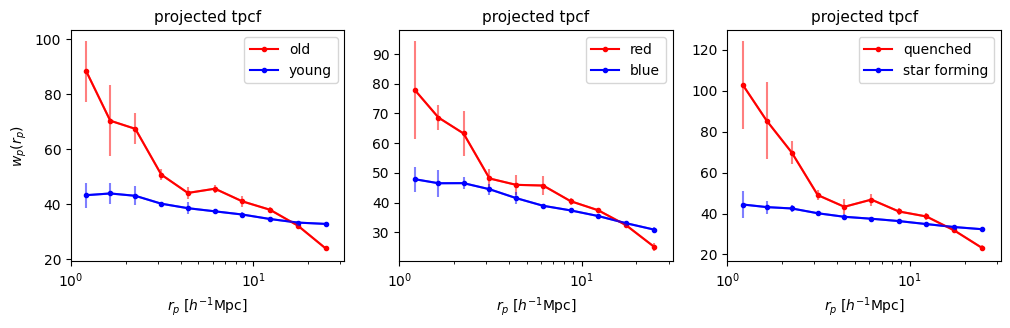

In [13]:
# plot
fig,ax = plt.subplots(1,3, figsize=(12, 3))

# with uncertainty using k-fold
ax[0].plot(ptpcf_old[0],ptpcf_old[1], marker = '.',
        color= 'Red', label = 'old')
ax[0].errorbar(ptpcf_old[0], ptpcf_old[1],
        yerr=uncertain1_old[1], color= 'Red', alpha = .5)
ax[0].plot(ptpcf_young[0],ptpcf_young[1], marker = '.',
        color= 'Blue', label = 'young')
ax[0].errorbar(ptpcf_young[0], ptpcf_young[1],
        yerr=uncertain1_young[1], color= 'Blue', alpha = .5)
ax[0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax[0].set_ylabel(r"$w_{p} (r_{p})$")
ax[0].set_title('projected tpcf', fontsize=11)
#ax[0].set_ylim(0,2.5)
ax[0].set_xlim(10e-1,10**(1.5))
ax[0].set_xscale('log')
ax[0].legend()

ax[1].plot(ptpcf_red[0],ptpcf_red[1], marker = '.',
        color= 'Red', label = 'red')
ax[1].errorbar(ptpcf_red[0], ptpcf_red[1],
        yerr=uncertain1_red[1], color= 'Red', alpha = .5)
ax[1].plot(ptpcf_blue[0],ptpcf_blue[1], marker = '.',
        color= 'Blue', label = 'blue')
ax[1].errorbar(ptpcf_blue[0], ptpcf_blue[1],
        yerr=uncertain1_blue[1], color= 'Blue', alpha = .5)
ax[1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[1].set_ylabel(r"$w_{p} (r_{p})$")
ax[1].set_title('projected tpcf', fontsize=11)
#ax[1].set_ylim(0,2.5)
ax[1].set_xlim(10e-1,10**(1.5))
ax[1].set_xscale('log')
ax[1].legend()

ax[2].plot(ptpcf_quenched[0],ptpcf_quenched[1], marker = '.',
        color= 'Red', label = 'quenched')
ax[2].errorbar(ptpcf_quenched[0], ptpcf_quenched[1],
        yerr=uncertain1_quenched[1], color= 'Red', alpha = .5)
ax[2].plot(ptpcf_starform[0],ptpcf_starform[1], marker = '.',
        color= 'Blue', label = 'star forming')
ax[2].errorbar(ptpcf_starform[0], ptpcf_starform[1],
        yerr=uncertain1_starform[1], color= 'Blue', alpha = .5)
ax[2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[2].set_ylabel(r"$w_{p} (r_{p})$")
ax[2].set_title('projected tpcf', fontsize=11)
#ax[0].set_ylim(0,2.5)
ax[2].set_xlim(10e-1,10**(1.5))
ax[2].set_xscale('log')
ax[2].legend();

- Apart from intersections which are not seen on the paper, there are also no bumps in our plots which means no small-scale clustering.</br>
- The trend is still well represented: older, redder and quenched galaxies cluster more strongly than young, blue star forming galaxies.</br>
- The values on the x-axis only start from $~10^{0}$ whereas in the paper, there are values lower than this. This might be due to the limited number of galaxies in our analysis.</br>
- Comparing $\xi (r)$ with the projected distances (not the real distance) and $w_{p}(r_{p})$, there does not seem to be much differences in terms of how the lines look in general.